# Importacion de librerias

In [2]:
import numpy as np
import pandas as pd
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.ensemble import RandomForestRegressor

from boruta import BorutaPy

from pycaret.classification import (setup, compare_models, create_model, pull,
                                    tune_model, plot_model, predict_model)

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import  OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

from funciones import calc_lift_acumulado

# Cargue de datos

In [3]:
df_retiro = pd.read_csv('../data/raw/base clasificacion.csv', sep=';')

In [4]:
df_retiro.columns

Index(['id_empresa', 'nit', 'sector', 'antiguedad', 'tiempo_afiliacion',
       'num_trabajadores', 'crecimiento_empleo', 'uso_servicios',
       'satisfaccion', 'rotacion', 'salario_promedio', 'digitalizacion',
       'formalizacion', 'distancia', 'abandono'],
      dtype='object')

# Entrenamiento y testeo de modelos

### Analisis de multicolinelidad

Este analisis lo realizamos con el fin de identifciar que varibles estan almanete relacionadas y evitar darle posible información redundante a los modelos lineales

In [5]:

X = df_retiro.select_dtypes(include=np.number)

# quitar variable objetivo
X = X.drop(columns=["abandono","id_empresa","nit"])

vif = pd.DataFrame()

vif["Variable"] = X.columns

vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif = vif.sort_values("VIF", ascending=False)

print(vif)

              Variable        VIF
9        formalizacion  34.190527
5         satisfaccion  29.505039
8       digitalizacion  24.014466
4        uso_servicios  10.809768
0           antiguedad  10.068322
1    tiempo_afiliacion   8.080506
7     salario_promedio   7.391273
6             rotacion   3.963944
10           distancia   2.007786
2     num_trabajadores   1.864092
3   crecimiento_empleo   1.247600


### Boruta

Se aplica boruta con el fin de identificar cuales son las variables que me aportan información útil en la predicción de la variable objetivo (aporte_mensual) y verificar si estas mismas hacen parte de las que cuentan con mayor multicolinealidad identificadas en el paso anterior

In [6]:
X = df_retiro.drop(columns=["abandono","id_empresa","nit","antiguedad"])
y = df_retiro['abandono']

In [7]:
numeric_features = X.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(
        handle_unknown='ignore',
        drop='first',
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop'
)

X_pre = preprocessor.fit_transform(X)
feature_names = preprocessor.get_feature_names_out()
X_pre = pd.DataFrame(
    X_pre,
    columns=feature_names,
    index=X.index
)

rf = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

boruta = BorutaPy(
    estimator=rf,
    n_estimators='auto',
    random_state=42
)

boruta.fit(X_pre.values, y.values)
variables = X_pre.columns[boruta.support_]

print(variables)

ranking = pd.DataFrame({
    "Variable": X_pre.columns,
    "Ranking": boruta.ranking_,
    "Seleccionada": boruta.support_
})

ranking.sort_values("Ranking")

Index(['num__tiempo_afiliacion', 'num__crecimiento_empleo',
       'num__uso_servicios', 'num__satisfaccion', 'num__rotacion',
       'num__digitalizacion', 'num__formalizacion'],
      dtype='object')


,Variable,Ranking,Seleccionada
0,num__tiempo_afiliacion,1,True
2,num__crecimiento_empleo,1,True
3,num__uso_servicios,1,True
4,num__satisfaccion,1,True
5,num__rotacion,1,True
7,num__digitalizacion,1,True
8,num__formalizacion,1,True
9,num__distancia,2,False
1,num__num_trabajadores,3,False
6,num__salario_promedio,4,False


Dados los resultdos de boruta, se decide continuar con las columnas sugeridas y validar su desempeño en el modelo

## Variables Boruta

In [8]:
variables_boruta = [
    "tiempo_afiliacion",
    "crecimiento_empleo",
    "uso_servicios",
    "satisfaccion",
    "rotacion",
    "digitalizacion",
    "formalizacion"
]

In [9]:
X = df_retiro[variables_boruta]
y = df_retiro['abandono']

x_train, x_test, y_train, y_test = train_test_split(X,y, random_state=42, test_size=0.2)

### PYCARET
Se hará uso de la libreria pycaret la cual nos permite automatizar flujos de tabajo de ML, preparando datos, entrenando y comparando resultados entre diferentes modelos optimizando el costo computacional

In [10]:
x_train["Target"]=y_train

s = setup(x_train,
            target = 'Target' 
        
            ,fold_strategy = 'kfold' 
            ,train_size = 0.7
        
            ,fix_imbalance= True 
            ,fix_imbalance_method = 'SMOTE'  
        
            ,remove_outliers = True
            ,outliers_method = 'iforest'
            ,outliers_threshold = 0.05
        
            ,normalize = True # normalizamos las variables metricas con z score para evitar una alta varianza entre las variables y que se nos sesguen los resultados al comportamiento de alguna en particular
            ,normalize_method = 'zscore'
        
            ,remove_multicollinearity = True
            ,multicollinearity_threshold = 0.8 # Variables con correlación superior al 90% son eliminadas, solo permanece la que tenga mayor corr con Y
        
            ,feature_selection_method = 'univariate' #Definimos el feature selecction: rankeo de las variables por medio de un test de Chi2
            ,n_features_to_select = 0.05 
            
            ,session_id = 123 #semilla
        
            ,n_jobs = -1
            ,use_gpu = False
            
            ,verbose=1
            
            )

best = compare_models(sort = 'F1',  
    include=[
    'lr',      # Logistic Regression
    'dt',      # Decision Tree
    'rf',      # Random Forest
    'et',      # Extra Trees
    'xgboost', # XGBoost
    'lightgbm',
    'gbc',     # Gradient Boosting
    'ada'      # AdaBoost
])

results = pull() 
results.sort_values('F1', ascending= False)
print(results)

model = create_model(best)
model_name=type(model).__name__
print("modelo seleccionado: "+ model_name)
results = pull() 
results.sort_values('F1', ascending= False)
print(results)

tuned_model = tune_model(model,  optimize='F1')

results = pull() 
results.sort_values('F1', ascending= False)
print(results)


,Description,Value
0,Session id,123
1,Target,Target
2,Target type,Binary
3,Original data shape,"(8000, 8)"
4,Transformed data shape,"(9836, 8)"
5,Transformed train set shape,"(7436, 8)"
6,Transformed test set shape,"(2400, 8)"
7,Numeric features,7
8,Preprocess,True
9,Imputation type,simple


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,Logistic Regression,0.7879,0.8705,0.7963,0.6143,0.6934,0.5352,0.5458,1.3500
gbc,Gradient Boosting Classifier,0.7934,0.8630,0.7137,0.6421,0.6758,0.5247,0.5265,0.2940
ada,Ada Boost Classifier,0.7830,0.8559,0.7243,0.6203,0.6681,0.5083,0.5117,0.1190
lightgbm,Light Gradient Boosting Machine,0.7961,0.8575,0.6705,0.6596,0.6648,0.5181,0.5183,0.1990
rf,Random Forest Classifier,0.7959,0.8529,0.6645,0.6612,0.6627,0.5162,0.5164,0.2920
et,Extra Trees Classifier,0.7941,0.8559,0.6551,0.6602,0.6574,0.5102,0.5104,0.1720
xgboost,Extreme Gradient Boosting,0.7930,0.8462,0.6537,0.6583,0.6556,0.5077,0.5079,0.1050
dt,Decision Tree Classifier,0.7300,0.6889,0.5850,0.5498,0.5665,0.3708,0.3714,0.9210


                                    Model  Accuracy     AUC  Recall   Prec.  \
lr                    Logistic Regression    0.7879  0.8705  0.7963  0.6143   
gbc          Gradient Boosting Classifier    0.7934  0.8630  0.7137  0.6421   
ada                  Ada Boost Classifier    0.7830  0.8559  0.7243  0.6203   
lightgbm  Light Gradient Boosting Machine    0.7961  0.8575  0.6705  0.6596   
rf               Random Forest Classifier    0.7959  0.8529  0.6645  0.6612   
et                 Extra Trees Classifier    0.7941  0.8559  0.6551  0.6602   
xgboost         Extreme Gradient Boosting    0.7930  0.8462  0.6537  0.6583   
dt               Decision Tree Classifier    0.7300  0.6889  0.5850  0.5498   

              F1   Kappa     MCC  TT (Sec)  
lr        0.6934  0.5352  0.5458     1.350  
gbc       0.6758  0.5247  0.5265     0.294  
ada       0.6681  0.5083  0.5117     0.119  
lightgbm  0.6648  0.5181  0.5183     0.199  
rf        0.6627  0.5162  0.5164     0.292  
et        0.6574  

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7839,0.8679,0.7921,0.6267,0.6998,0.5346,0.5435
1,0.7804,0.8639,0.7901,0.5899,0.6755,0.5147,0.5273
2,0.7857,0.8723,0.7800,0.5735,0.6610,0.5096,0.5225
3,0.7679,0.8376,0.7765,0.6070,0.6814,0.5031,0.5125
4,0.7929,0.8717,0.8023,0.6273,0.7041,0.5484,0.5582
5,0.7946,0.8625,0.7874,0.6372,0.7044,0.5497,0.5569
6,0.7696,0.8738,0.7605,0.5880,0.6632,0.4925,0.5019
7,0.7929,0.8681,0.8193,0.6126,0.7010,0.5476,0.5611
8,0.8018,0.9020,0.8208,0.6396,0.7190,0.5695,0.5801


modelo seleccionado: LogisticRegression
      Accuracy     AUC  Recall   Prec.      F1   Kappa     MCC
Fold                                                          
0       0.7839  0.8679  0.7921  0.6267  0.6998  0.5346  0.5435
1       0.7804  0.8639  0.7901  0.5899  0.6755  0.5147  0.5273
2       0.7857  0.8723  0.7800  0.5735  0.6610  0.5096  0.5225
3       0.7679  0.8376  0.7765  0.6070  0.6814  0.5031  0.5125
4       0.7929  0.8717  0.8023  0.6273  0.7041  0.5484  0.5582
5       0.7946  0.8625  0.7874  0.6372  0.7044  0.5497  0.5569
6       0.7696  0.8738  0.7605  0.5880  0.6632  0.4925  0.5019
7       0.7929  0.8681  0.8193  0.6126  0.7010  0.5476  0.5611
8       0.8018  0.9020  0.8208  0.6396  0.7190  0.5695  0.5801
9       0.8089  0.8850  0.8343  0.6409  0.7249  0.5824  0.5943
Mean    0.7879  0.8705  0.7963  0.6143  0.6934  0.5352  0.5458
Std     0.0124  0.0156  0.0216  0.0228  0.0210  0.0281  0.0282


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7839,0.8676,0.7921,0.6267,0.6998,0.5346,0.5435
1,0.7821,0.8639,0.7901,0.5926,0.6772,0.5178,0.5301
2,0.7875,0.8723,0.7867,0.5756,0.6648,0.5146,0.5281
3,0.7661,0.8377,0.7765,0.6043,0.6797,0.4999,0.5097
4,0.7929,0.8718,0.8023,0.6273,0.7041,0.5484,0.5582
5,0.7946,0.8624,0.7874,0.6372,0.7044,0.5497,0.5569
6,0.7714,0.8741,0.7605,0.5907,0.6649,0.4956,0.5047
7,0.7929,0.8685,0.8193,0.6126,0.7010,0.5476,0.5611
8,0.8036,0.9020,0.8208,0.6425,0.7208,0.5727,0.5830


Fitting 10 folds for each of 10 candidates, totalling 100 fits
      Accuracy     AUC  Recall   Prec.      F1   Kappa     MCC
Fold                                                          
0       0.7839  0.8676  0.7921  0.6267  0.6998  0.5346  0.5435
1       0.7821  0.8639  0.7901  0.5926  0.6772  0.5178  0.5301
2       0.7875  0.8723  0.7867  0.5756  0.6648  0.5146  0.5281
3       0.7661  0.8377  0.7765  0.6043  0.6797  0.4999  0.5097
4       0.7929  0.8718  0.8023  0.6273  0.7041  0.5484  0.5582
5       0.7946  0.8624  0.7874  0.6372  0.7044  0.5497  0.5569
6       0.7714  0.8741  0.7605  0.5907  0.6649  0.4956  0.5047
7       0.7929  0.8685  0.8193  0.6126  0.7010  0.5476  0.5611
8       0.8036  0.9020  0.8208  0.6425  0.7208  0.5727  0.5830
9       0.8089  0.8850  0.8343  0.6409  0.7249  0.5824  0.5943
Mean    0.7884  0.8705  0.7970  0.6150  0.6942  0.5363  0.5470
Std     0.0126  0.0156  0.0212  0.0223  0.0204  0.0277  0.0279


In [11]:
#Modelo seleccionado
tuned_model

LogisticRegression(C=0.049, class_weight='balanced', dual=False,
                   fit_intercept=True, intercept_scaling=1, l1_ratio=None,
                   max_iter=1000, multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=123, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

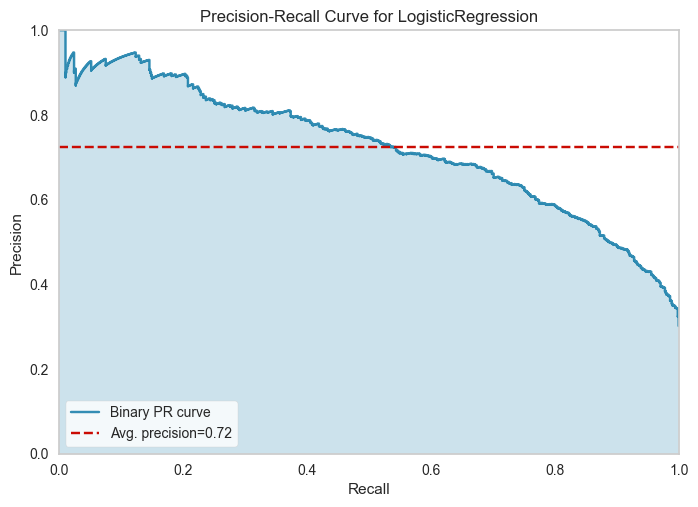

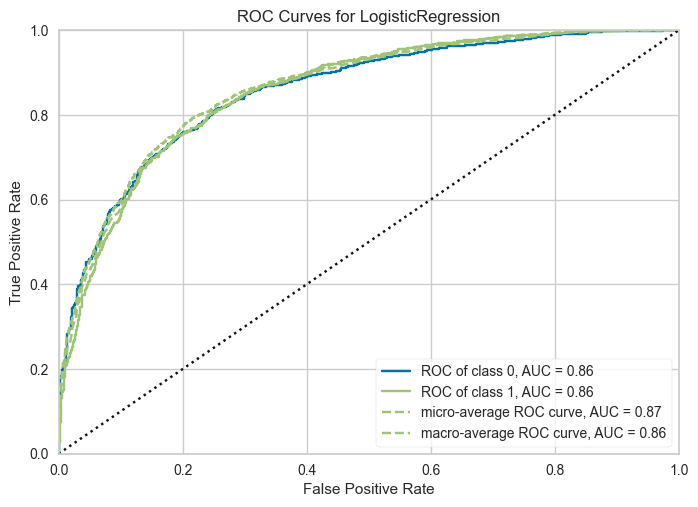

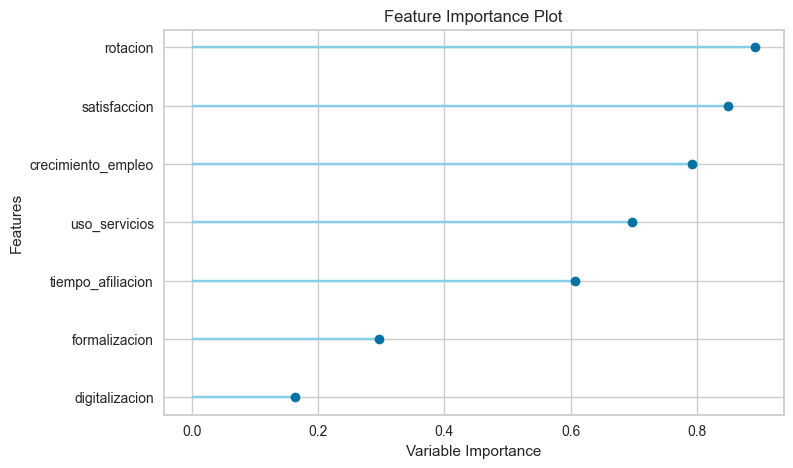

Index(['tiempo_afiliacion', 'crecimiento_empleo', 'uso_servicios',
       'satisfaccion', 'rotacion', 'digitalizacion', 'formalizacion',
       'prediction_label', 'prediction_score_0', 'prediction_score_1'],
      dtype='object')


In [12]:

plot_model(tuned_model, plot = 'pr') 
plot_model(tuned_model, plot = 'auc') 
plot_model(tuned_model, plot = 'feature')

resultados_test=predict_model(tuned_model, data=x_test ,raw_score=True)
print(resultados_test.columns)


In [13]:
resultados_test['abandono_real'] = y_test

In [14]:
resultados_test

,tiempo_afiliacion,crecimiento_empleo,uso_servicios,satisfaccion,rotacion,digitalizacion,formalizacion,prediction_label,prediction_score_0,prediction_score_1,abandono_real
6252,9.4,11.6,7,81.900002,2.800000,76.000000,63.000000,0,0.9928,0.0072,0
4684,8.3,9.8,5,59.099998,14.400000,22.700001,53.599998,0,0.6727,0.3273,0
1731,18.4,5.3,1,57.599998,34.299999,70.599998,55.200001,1,0.2273,0.7727,0
4742,11.7,4.2,7,75.199997,5.400000,66.900002,52.900002,0,0.9754,0.0246,0
4521,6.0,-3.9,4,59.700001,32.700001,47.099998,59.000000,1,0.0825,0.9175,0
...,...,...,...,...,...,...,...,...,...,...,...
6412,0.5,6.2,7,74.900002,4.900000,70.599998,53.799999,0,0.9184,0.0816,0
8285,8.5,1.4,5,65.900002,16.900000,20.900000,28.000000,1,0.4403,0.5597,1
7853,3.0,6.4,4,66.000000,10.800000,64.300003,71.199997,0,0.7059,0.2941,0
1095,4.4,6.8,0,37.500000,24.600000,53.599998,57.500000,1,0.0214,0.9786,1


              precision    recall  f1-score   support

           0       0.81      0.88      0.84      1280
           1       0.74      0.63      0.68       720

    accuracy                           0.79      2000
   macro avg       0.77      0.75      0.76      2000
weighted avg       0.78      0.79      0.78      2000



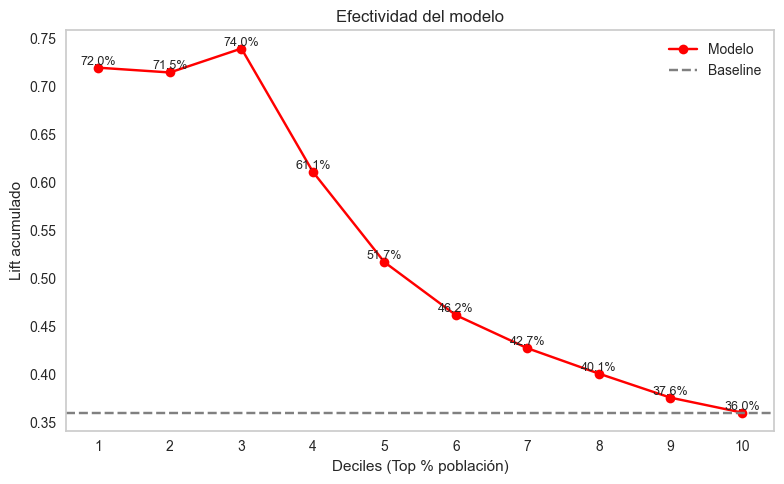

In [ ]:
print(classification_report(resultados_test['prediction_label'], resultados_test['abandono_real']))
lift_df_B, baseline_B = calc_lift_acumulado(resultados_test['prediction_label'], resultados_test['abandono_real'])

In [25]:
resultados_test = resultados_test.sort_values(by='prediction_score_1',ascending=False).reset_index(drop=True)
resultados_test['bin'] = pd.qcut(resultados_test.index, 10, labels=False)

In [34]:
resultados_test[resultados_test['bin'] == 3]['prediction_score_1'].max()

0.5907

In [16]:
joblib.dump(tuned_model, "../models/modelo_clasificacion.pkl")

['../models/modelo_clasificacion.pkl']